# Lambda Experiments

## Tranining

In [1]:
import sys
sys.path.append("..")

from source.system import SystemParams
from source.policy import NeuralPolicy

from source.utils import read_csv
from source.training import train_net

In [5]:
import torch
import os

EPOCHS       = 500
LR           = 0.01
WEIGHT_DECAY = 1e-5
BATCH_SIZE   = 1000
SEED_BASE    = 123
LAMBDA_COST  = [0.1, 0.25, 0.5]
LAMBDA_DEMAND = 0.0
ALPHA_GRID   = 0.0
DEVICE       = torch.device("cpu")

params = SystemParams()
S0_single = torch.tensor([[0., 0., 100., 0.01]], device=DEVICE)

energy_prices = read_csv("../data/eprice_test.csv")
price_history = energy_prices[:params.T]
future_price = energy_prices[params.T:]

CHECKPOINT_DIR = "../checkpoints/lambda_experiments"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Same initial weights for all lambda experiments
torch.manual_seed(SEED_BASE)
initial_policy = NeuralPolicy().to(DEVICE)
initial_state = {
    k: v.detach().cpu().clone()
    for k, v in initial_policy.state_dict().items()
}

for lambda_cost in LAMBDA_COST:

    print("=" * 50)
    print(f"Training: lambda={lambda_cost}")

    # Reset policy to the same initial weights
    policy = NeuralPolicy().to(DEVICE)
    policy.load_state_dict(initial_state)

    opt = torch.optim.AdamW(
        policy.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    res = train_net(
        policy=policy,
        optimizer=opt,
        device=DEVICE,
        params=params,
        S0_single=S0_single,
        endog_history=price_history,
        future_endog=future_price,
        epochs=EPOCHS,
        lambda_cost=lambda_cost,
        lambda_demand=LAMBDA_DEMAND,
        alpha_grid=ALPHA_GRID,
        batch_size=BATCH_SIZE,
        seed_base=SEED_BASE,
        verbose=True
    )

    print(f"lambda: {lambda_cost}, best J: {res['best_J']}")

    filename = f"policy_lambda_{str(lambda_cost).replace('.', '_')}_new_lr.pt"
    path = os.path.join(CHECKPOINT_DIR, filename)

    checkpoint = {
        "lambda_cost": lambda_cost,
        "alpha_grid": ALPHA_GRID,
        "best_J": res["best_J"],
        "policy_state_dict": res["best_state"],
        "J_train_hist": res["J_train_hist"],
        'J_stoch_eval_hist': res['J_stoch_eval_hist'],
        'J_det_eval_hist': res['J_det_eval_hist'],
        "training_steps": res["training_steps"],
        "evaluation_steps": res["evaluation_steps"],
        "seed_base": SEED_BASE,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
    }

    if "best_epoch" in res:
        checkpoint["best_epoch"] = res["best_epoch"]

    torch.save(checkpoint, path)

    print(f"Saved best policy: {path}\n")

Training: lambda=0.1
[025] J_train=-1.0687 | J_stoch_eval_fixed=-1.1830 | J_det_eval=-1.8304
[050] J_train=-5.0091 | J_stoch_eval_fixed=-5.0336 | J_det_eval=-12.4059
[075] J_train=-5.8970 | J_stoch_eval_fixed=-5.6965 | J_det_eval=-12.9892
[100] J_train=-6.2453 | J_stoch_eval_fixed=-5.9794 | J_det_eval=-13.1464
[125] J_train=-6.3735 | J_stoch_eval_fixed=-6.1745 | J_det_eval=-13.0987
[150] J_train=-6.4574 | J_stoch_eval_fixed=-6.3150 | J_det_eval=-13.4082
[175] J_train=-6.5358 | J_stoch_eval_fixed=-6.2119 | J_det_eval=-13.2888
[200] J_train=-6.4699 | J_stoch_eval_fixed=-6.3776 | J_det_eval=-13.3664
[225] J_train=-6.3976 | J_stoch_eval_fixed=-6.3854 | J_det_eval=-13.5750
[250] J_train=-6.5148 | J_stoch_eval_fixed=-6.3601 | J_det_eval=-13.8860
[275] J_train=-6.7473 | J_stoch_eval_fixed=-6.3946 | J_det_eval=-13.3612
[300] J_train=-6.8499 | J_stoch_eval_fixed=-6.5754 | J_det_eval=-13.4655
[325] J_train=-6.6298 | J_stoch_eval_fixed=-6.6771 | J_det_eval=-13.6527
[350] J_train=-6.9446 | J_stoch

In [2]:
import torch
import os

EPOCHS       = 5000
LR           = 0.0025
WEIGHT_DECAY = 1e-5
BATCH_SIZE   = 1000
SEED_BASE    = 123
LAMBDA_COST  = [0.50]
LAMBDA_DEMAND = 0.0
ALPHA_GRID   = 0.0
DEVICE       = torch.device("cpu")

params = SystemParams()
S0_single = torch.tensor([[0., 0., 100., 0.01]], device=DEVICE)

energy_prices = read_csv("../data/eprice_test.csv")
price_history = energy_prices[:params.T]
future_price = energy_prices[params.T:]

CHECKPOINT_DIR = "../checkpoints/lambda_experiments"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Same initial weights for all lambda experiments
torch.manual_seed(SEED_BASE)
initial_policy = NeuralPolicy().to(DEVICE)
initial_state = {
    k: v.detach().cpu().clone()
    for k, v in initial_policy.state_dict().items()
}

for lambda_cost in LAMBDA_COST:

    print("=" * 50)
    print(f"Training: lambda={lambda_cost}")

    # Reset policy to the same initial weights
    policy = NeuralPolicy().to(DEVICE)
    policy.load_state_dict(initial_state)

    opt = torch.optim.AdamW(
        policy.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    res = train_net(
        policy=policy,
        optimizer=opt,
        device=DEVICE,
        params=params,
        S0_single=S0_single,
        endog_history=price_history,
        future_endog=future_price,
        epochs=EPOCHS,
        lambda_cost=lambda_cost,
        lambda_demand=LAMBDA_DEMAND,
        alpha_grid=ALPHA_GRID,
        batch_size=BATCH_SIZE,
        seed_base=SEED_BASE,
        verbose=True
    )

    print(f"lambda: {lambda_cost}, best J: {res['best_J']}")

    filename = f"policy_lambda_{str(lambda_cost).replace('.', '_')}_new_lr.pt"
    path = os.path.join(CHECKPOINT_DIR, filename)

    checkpoint = {
        "lambda_cost": lambda_cost,
        "alpha_grid": ALPHA_GRID,
        "best_J": res["best_J"],
        "policy_state_dict": res["best_state"],
        "J_train_hist": res["J_train_hist"],
        'J_stoch_eval_hist': res['J_stoch_eval_hist'],
        'J_det_eval_hist': res['J_det_eval_hist'],
        "training_steps": res["training_steps"],
        "evaluation_steps": res["evaluation_steps"],
        "seed_base": SEED_BASE,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
    }

    if "best_epoch" in res:
        checkpoint["best_epoch"] = res["best_epoch"]

    torch.save(checkpoint, path)

    print(f"Saved best policy: {path}\n")

Training: lambda=0.5
[250] J_train=-18.0507 | J_stoch_eval_fixed=-18.0807 | J_det_eval=5.4694
[500] J_train=-18.9981 | J_stoch_eval_fixed=-18.9615 | J_det_eval=10.6533
[750] J_train=-19.4696 | J_stoch_eval_fixed=-19.4487 | J_det_eval=10.3838
[1000] J_train=-19.7339 | J_stoch_eval_fixed=-19.6269 | J_det_eval=8.7797
[1250] J_train=-20.3176 | J_stoch_eval_fixed=-20.2775 | J_det_eval=8.1232
[1500] J_train=-20.5047 | J_stoch_eval_fixed=-20.3700 | J_det_eval=0.6908
[1750] J_train=-20.7659 | J_stoch_eval_fixed=-20.7082 | J_det_eval=7.1289
[2000] J_train=-20.9510 | J_stoch_eval_fixed=-20.9386 | J_det_eval=-0.1025
[2250] J_train=-21.2992 | J_stoch_eval_fixed=-21.0306 | J_det_eval=0.1746
[2500] J_train=-20.9257 | J_stoch_eval_fixed=-21.1350 | J_det_eval=0.5812
[2750] J_train=-21.2900 | J_stoch_eval_fixed=-21.2085 | J_det_eval=0.1703
[3000] J_train=-21.2400 | J_stoch_eval_fixed=-21.2653 | J_det_eval=0.3077
[3250] J_train=-21.4128 | J_stoch_eval_fixed=-21.2130 | J_det_eval=0.6272
[3500] J_train=-2

## Traning convergence

In [5]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

CHECKPOINT_DIR = "../checkpoints/lambda_experiments"
LAMBDA_COST = [0.0, 0.1, 0.25, 0.50]

checkpoints = {}

for lambda_cost in LAMBDA_COST:
    filename = f"policy_lambda_{str(lambda_cost).replace('.', '_')}_new_lr.pt"
    path = os.path.join(CHECKPOINT_DIR, filename)

    ckpt = torch.load(path, map_location="cpu")
    checkpoints[lambda_cost] = ckpt

    print("=" * 50)
    print(f"lambda = {lambda_cost}")
    print(f"best_J = {ckpt['best_J']}")

lambda = 0.0
best_J = -32.61921310424805
lambda = 0.1
best_J = -29.00250816345215
lambda = 0.25
best_J = -25.368167877197266
lambda = 0.5
best_J = -21.3610897064209


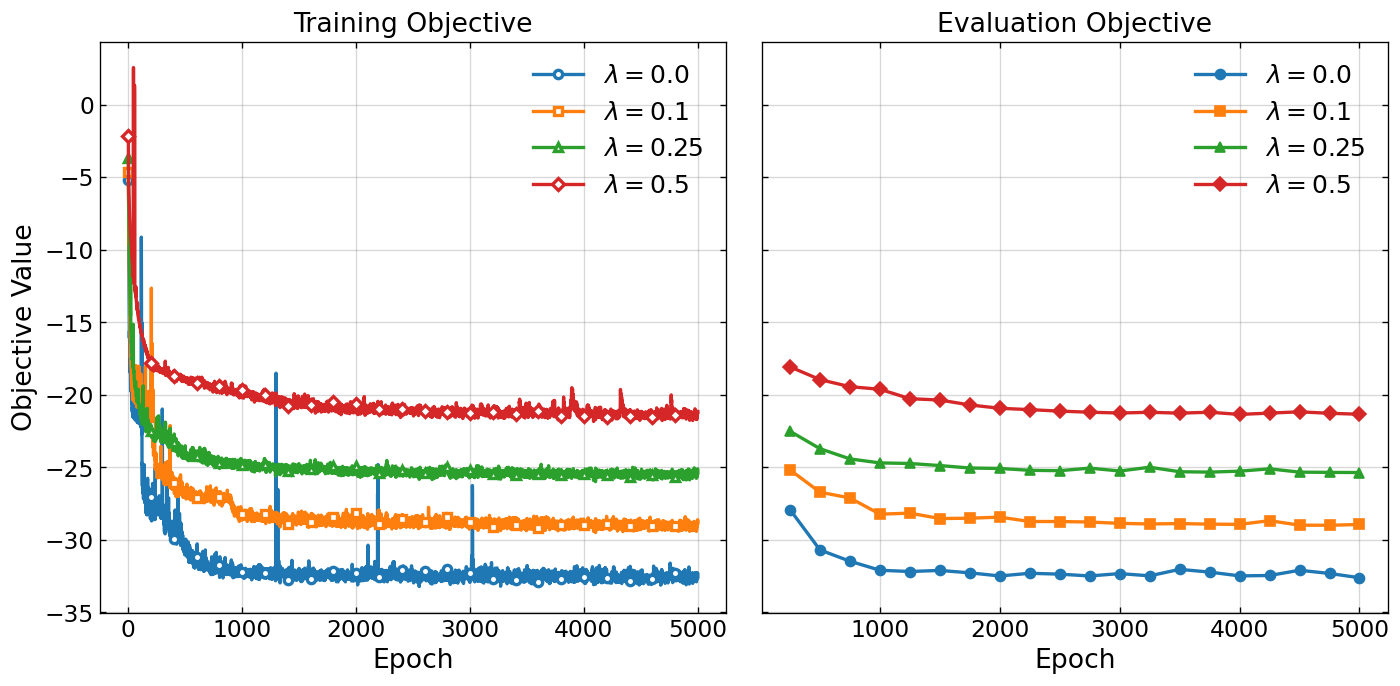

In [23]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("../styles/paper.mplstyle")

fig, axs = plt.subplots(
    1, 2,
    figsize=(12, 6),
    sharey=True
)

markers = ["o", "s", "^", "D"]

for marker, lambda_cost in zip(markers, LAMBDA_COST):

    filename = f"policy_lambda_{str(lambda_cost).replace('.', '_')}_new_lr.pt"
    path = os.path.join(CHECKPOINT_DIR, filename)

    ckpt = torch.load(path, map_location="cpu")

    J_train = ckpt["J_train_hist"]
    J_evaluation = ckpt["J_stoch_eval_hist"]
    training_steps = ckpt["training_steps"]
    evaluation_steps = ckpt["evaluation_steps"]

    axs[0].plot(
        training_steps,
        J_train,
        linestyle="-",
        marker=marker,
        markevery=200,
        markersize=5,
        linewidth=2,
        markerfacecolor="white",
        markeredgewidth=2,
        label=fr"$\lambda={lambda_cost}$"
    )

    axs[1].plot(
        evaluation_steps,
        J_evaluation,
        linestyle="-",
        marker=marker,
        markersize=6,
        linewidth=2,
        label=fr"$\lambda={lambda_cost}$"
    )

axs[0].set_title("Training Objective")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Objective Value")
axs[0].grid(True, alpha=0.3)

axs[1].set_title("Evaluation Objective")
axs[1].set_xlabel("Epoch")
axs[1].grid(True, alpha=0.3)

axs[0].legend(frameon=False)
axs[1].legend(frameon=False)

plt.tight_layout()

plt.savefig(
    "../figures/lambda_experiments/training_evaluation_objective.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "../figures/lambda_experiments/training_evaluation_objective.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Comparison

In [10]:
import sys
sys.path.append("..")

import torch
import os

from source.system import SystemParams
from source.simulation import sample_initial_state, rollout_trajectory
from source.stochastic_processes import make_price_function
from source.utils import read_csv
from source.policy import NeuralPolicy

DEVICE = torch.device("cpu")

POLICY_DIR = "../checkpoints/lambda_experiments"
ROLLOUT_DIR = "../checkpoints/rollouts"
os.makedirs(ROLLOUT_DIR, exist_ok=True)

LAMBDA_COST = [0.0, 0.1, 0.25, 0.5]

ALPHA_GRID = 0.0
BATCH_SIZE = 1000
SEED_BASE = 123

params = SystemParams()

S0 = sample_initial_state(
    batch_size=BATCH_SIZE,
    params=params,
    device=DEVICE,
    seed=SEED_BASE
)

energy_prices = read_csv("../data/eprice_test.csv")
price_history = energy_prices[:params.T]
future_price = energy_prices[params.T:]



rollout_results = {}

for lambda_cost in LAMBDA_COST:

    next_price_fn_eval = make_price_function(
        price_history,
        future_price,
        params
    )

    print("=" * 50)
    print(f"Rollout: lambda={lambda_cost}")

    filename = f"policy_lambda_{str(lambda_cost).replace('.', '_')}_new_lr.pt"
    path = os.path.join(POLICY_DIR, filename)

    ckpt = torch.load(path, map_location=DEVICE)

    policy = NeuralPolicy().to(DEVICE)
    policy.load_state_dict(ckpt["policy_state_dict"])
    policy.eval()

    with torch.no_grad():
        history = rollout_trajectory(
            policy=policy,
            S0=S0,
            lambda_cost=lambda_cost,
            lambda_demand=0.0,
            alpha_grid=ALPHA_GRID,
            params=params,
            next_price_fn=next_price_fn_eval,
            stochastic=True,
            seed=SEED_BASE,
            device=DEVICE,
        )

    lambda_key = str(lambda_cost)

    rollout_results[lambda_key] = history

    print(f"J_episode: {history['J_episode']}")

rollout_path = os.path.join(ROLLOUT_DIR, "lambda_experiment.pt")

torch.save(rollout_results, rollout_path)

print(f"\nSaved rollouts: {rollout_path}")

Rollout: lambda=0.0
J_episode: -32.478355407714844
Rollout: lambda=0.1
J_episode: -29.295734405517578
Rollout: lambda=0.25
J_episode: -26.14960479736328
Rollout: lambda=0.5
J_episode: -21.419565200805664

Saved rollouts: ../checkpoints/rollouts\lambda_experiment.pt


In [11]:
import sys
import os
sys.path.append("..")

import torch

import matplotlib.pyplot as plt

plt.style.use("../styles/notebook.mplstyle")

from source.plotting import *

rollout_results = torch.load("../checkpoints/rollouts/lambda_experiment.pt")

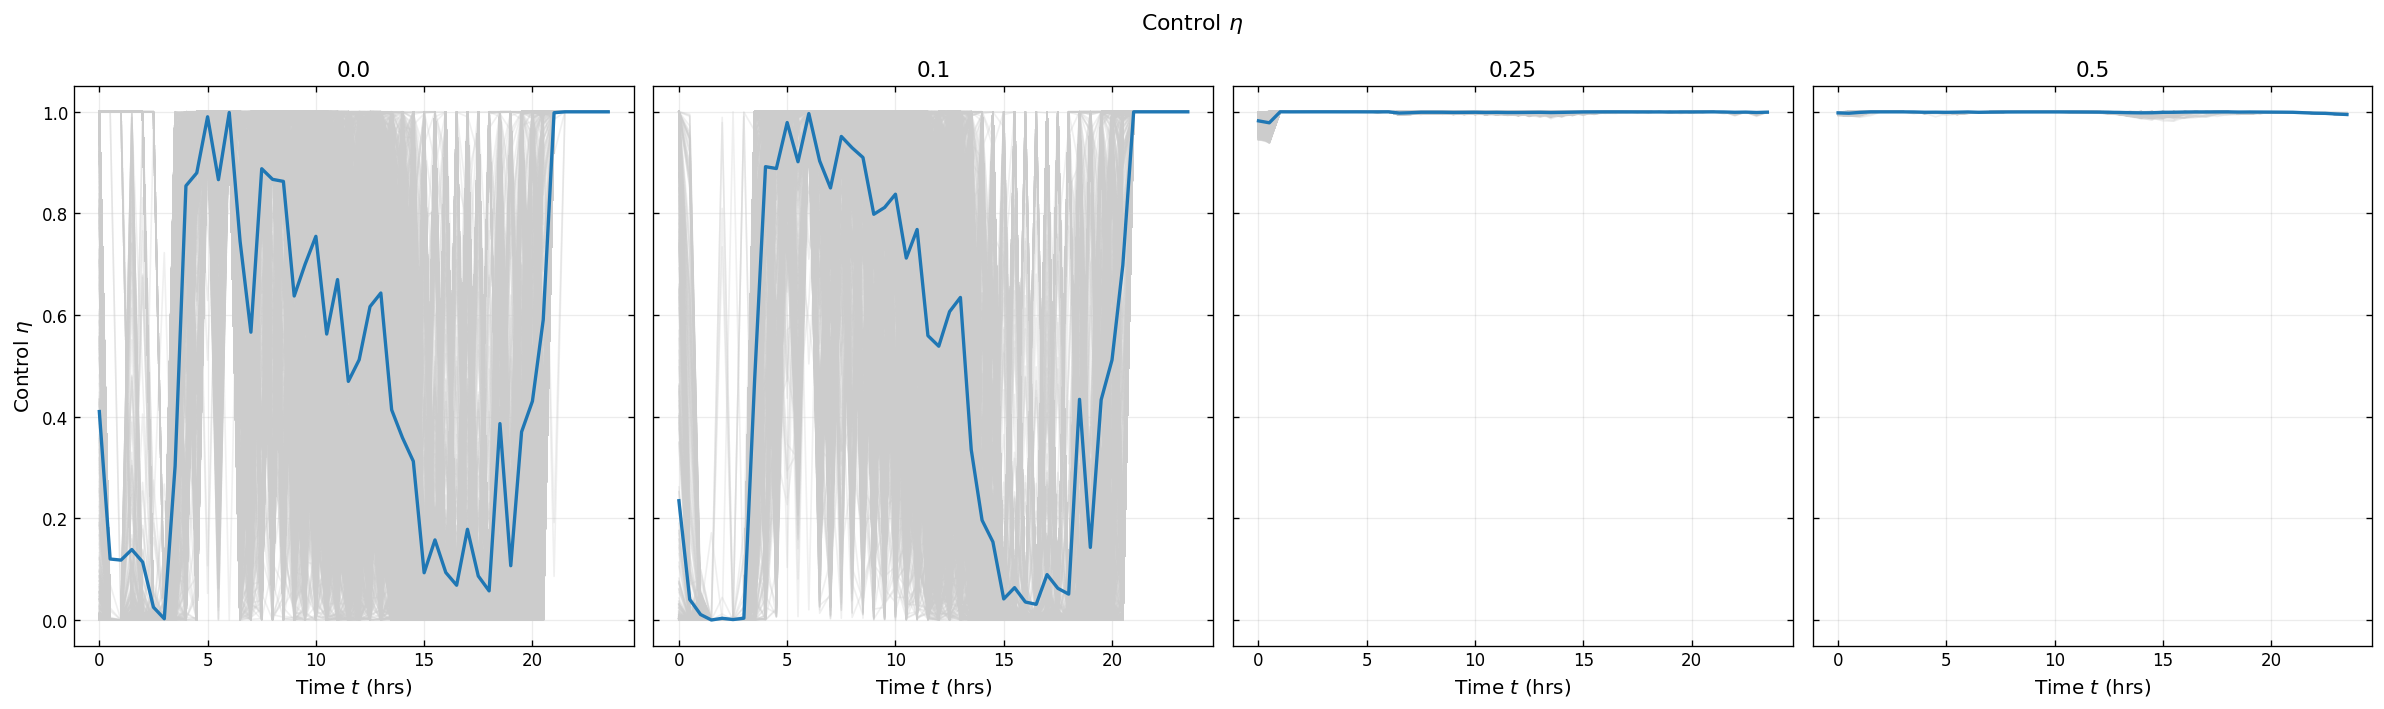

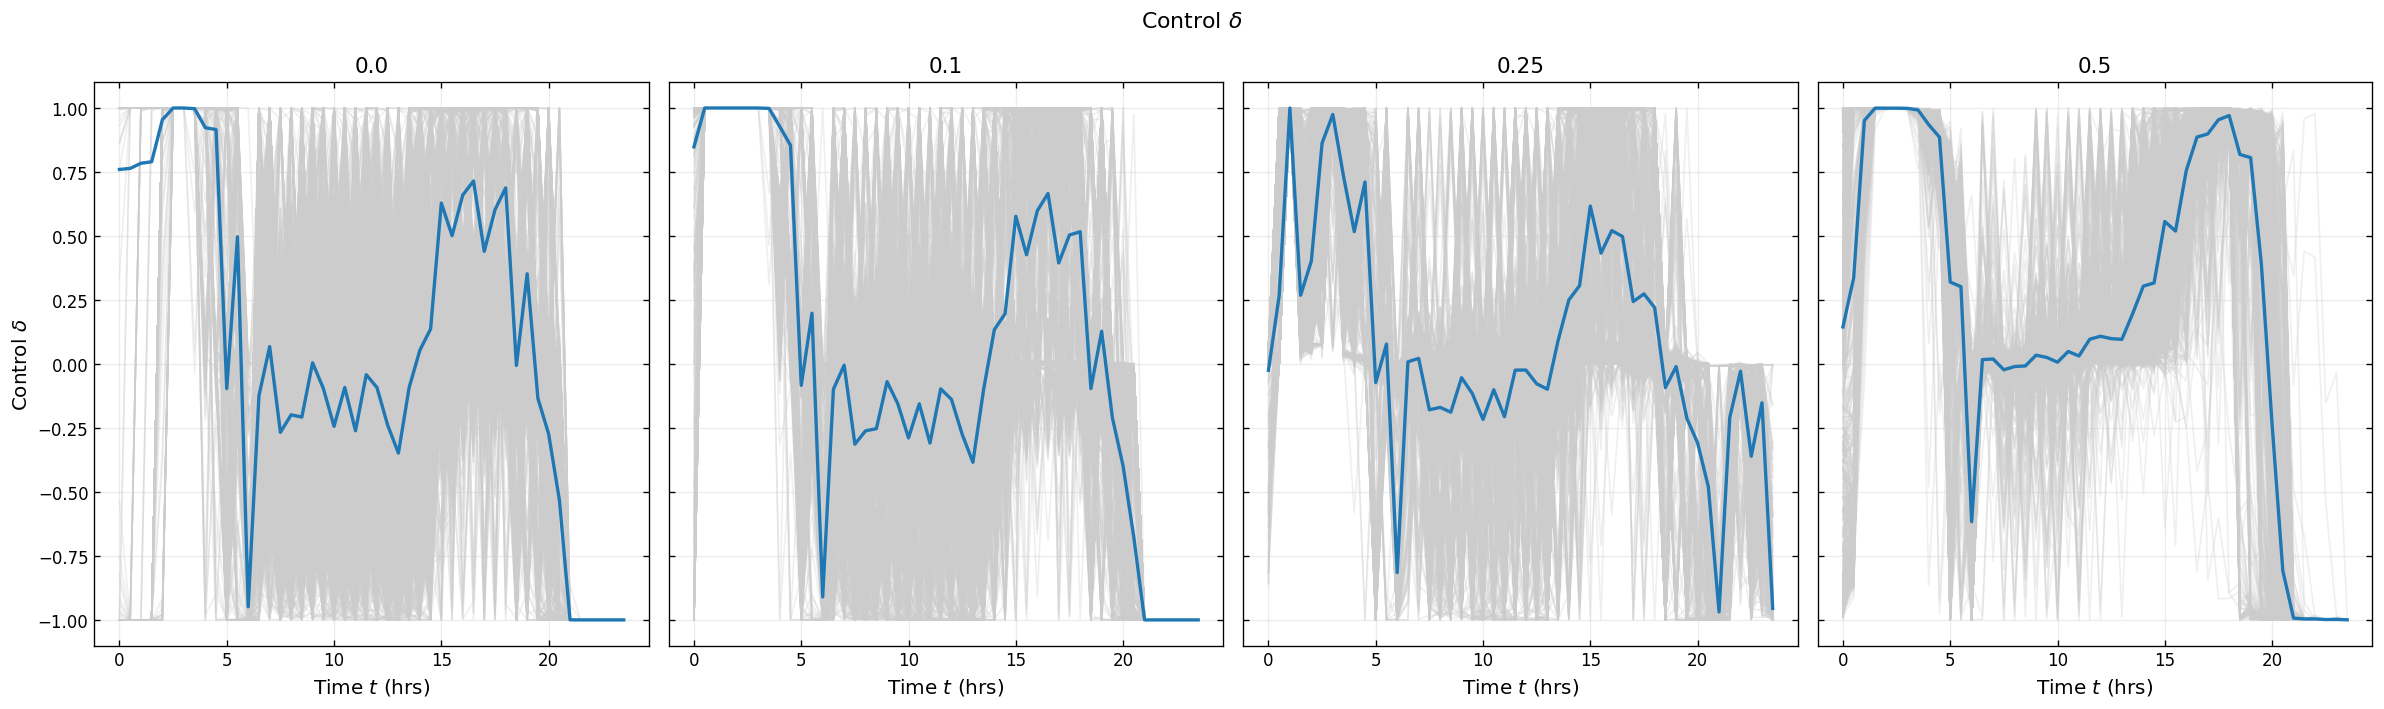

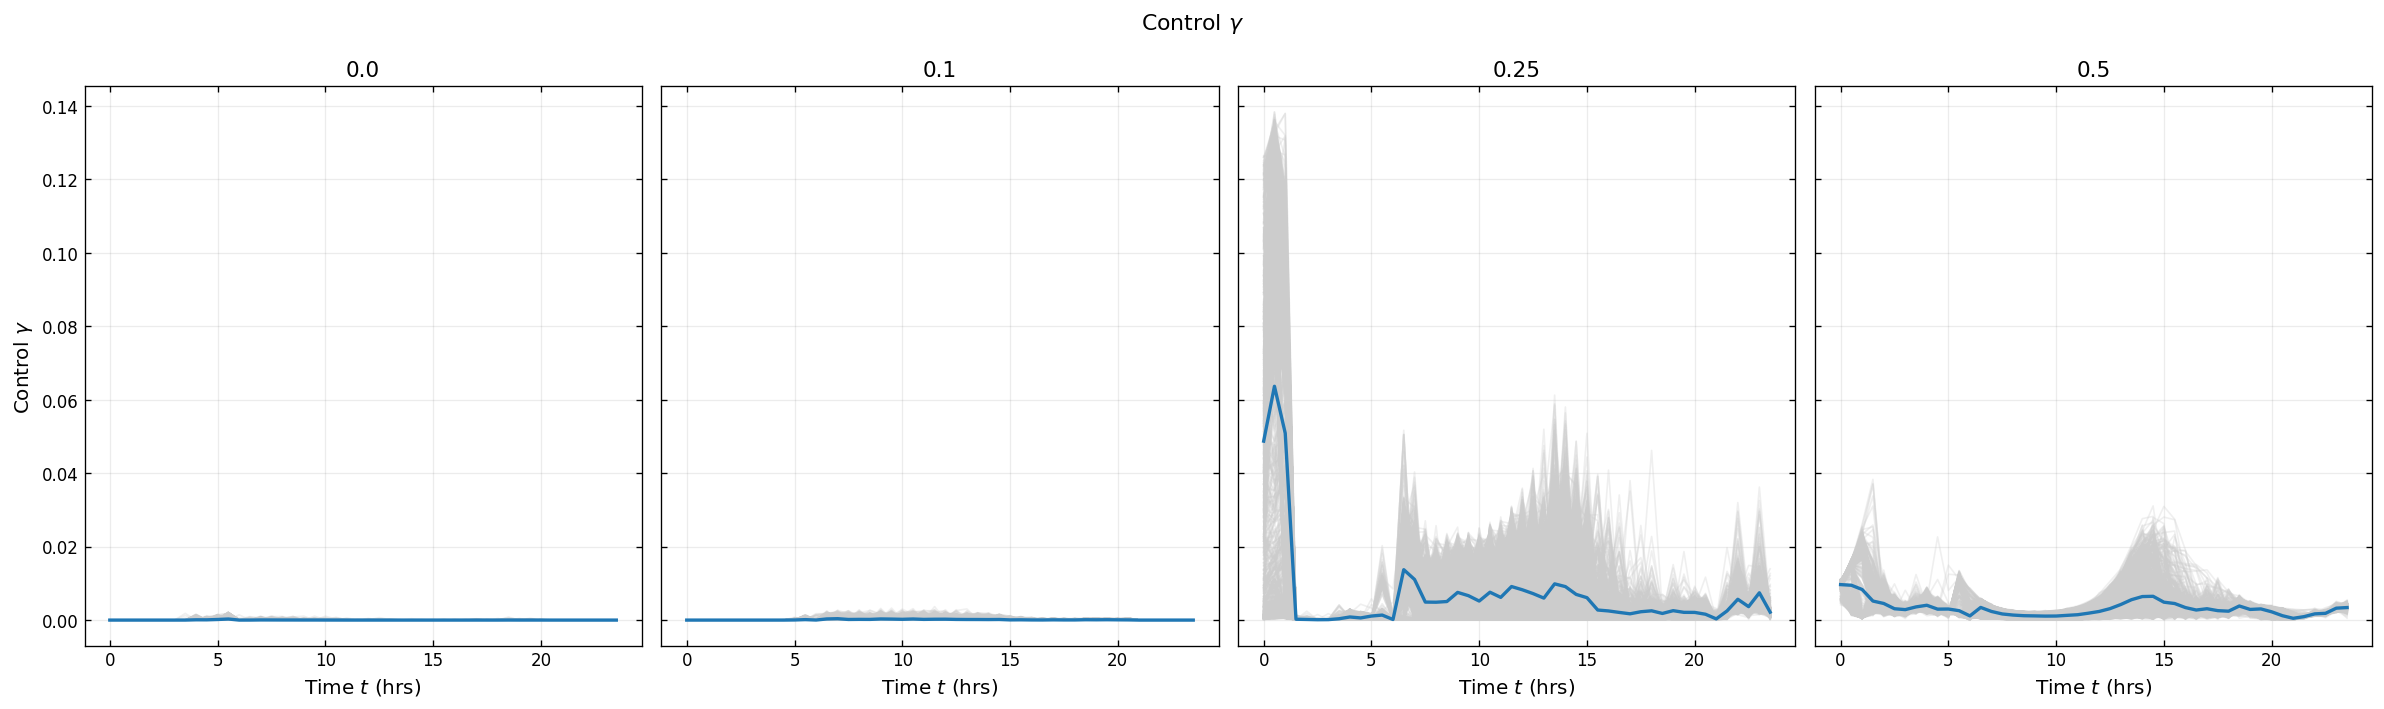

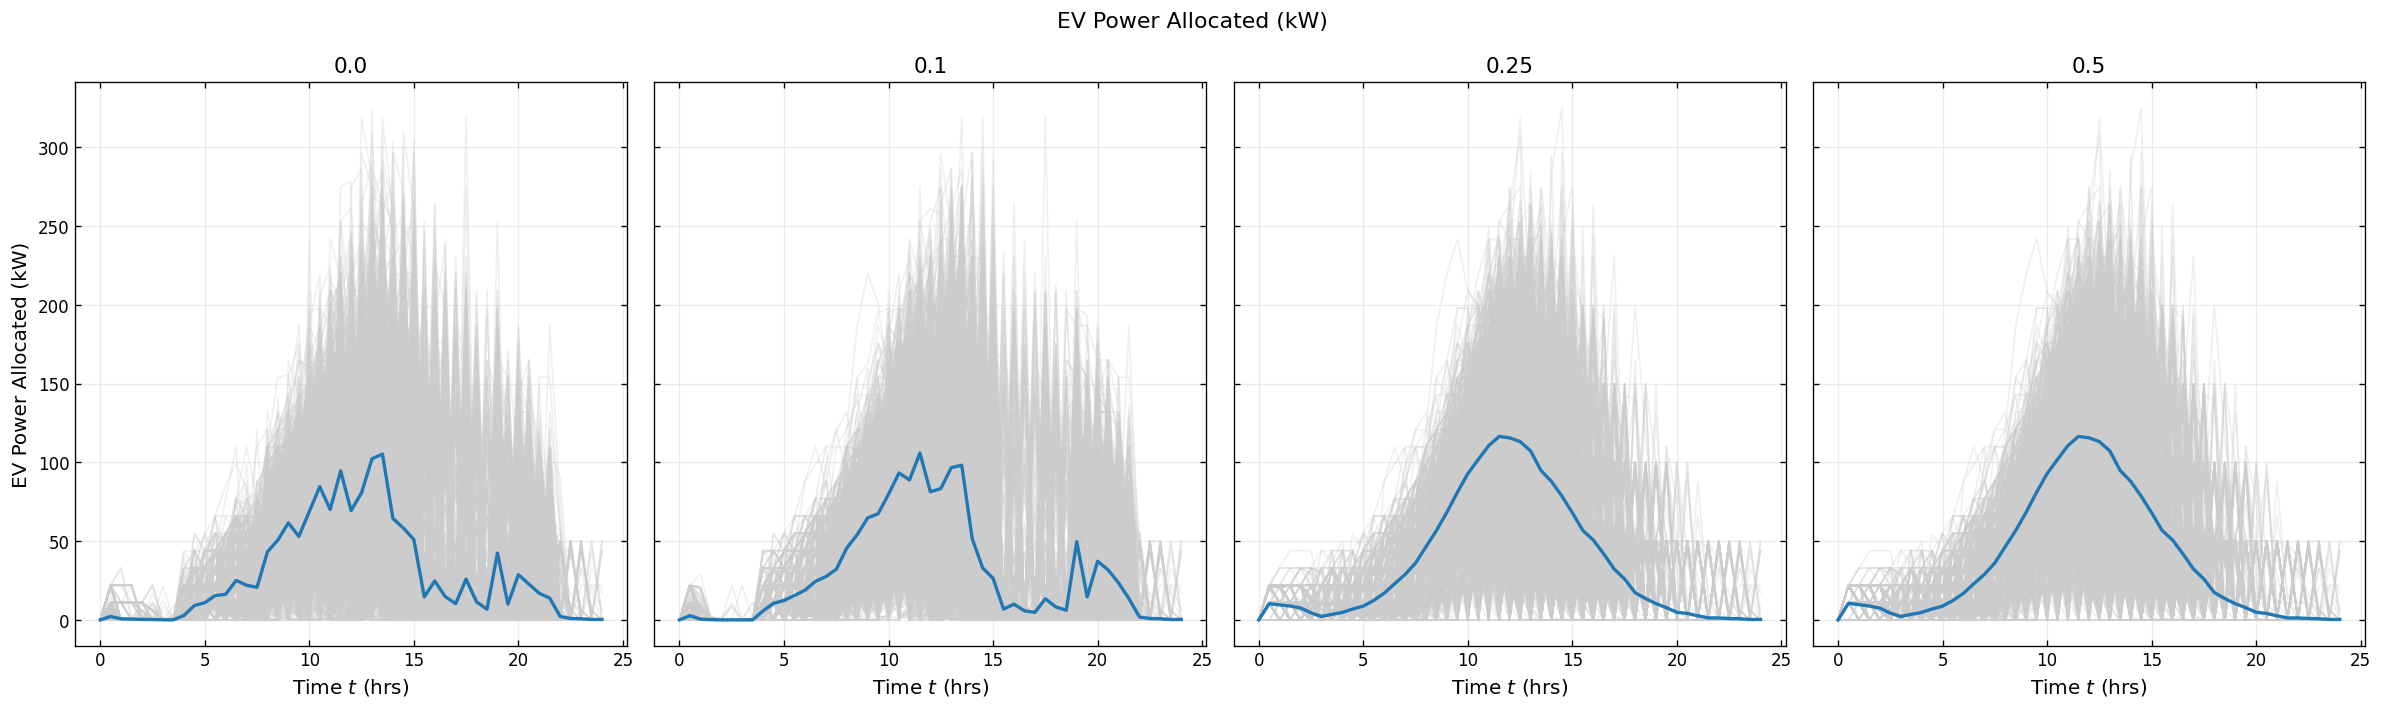

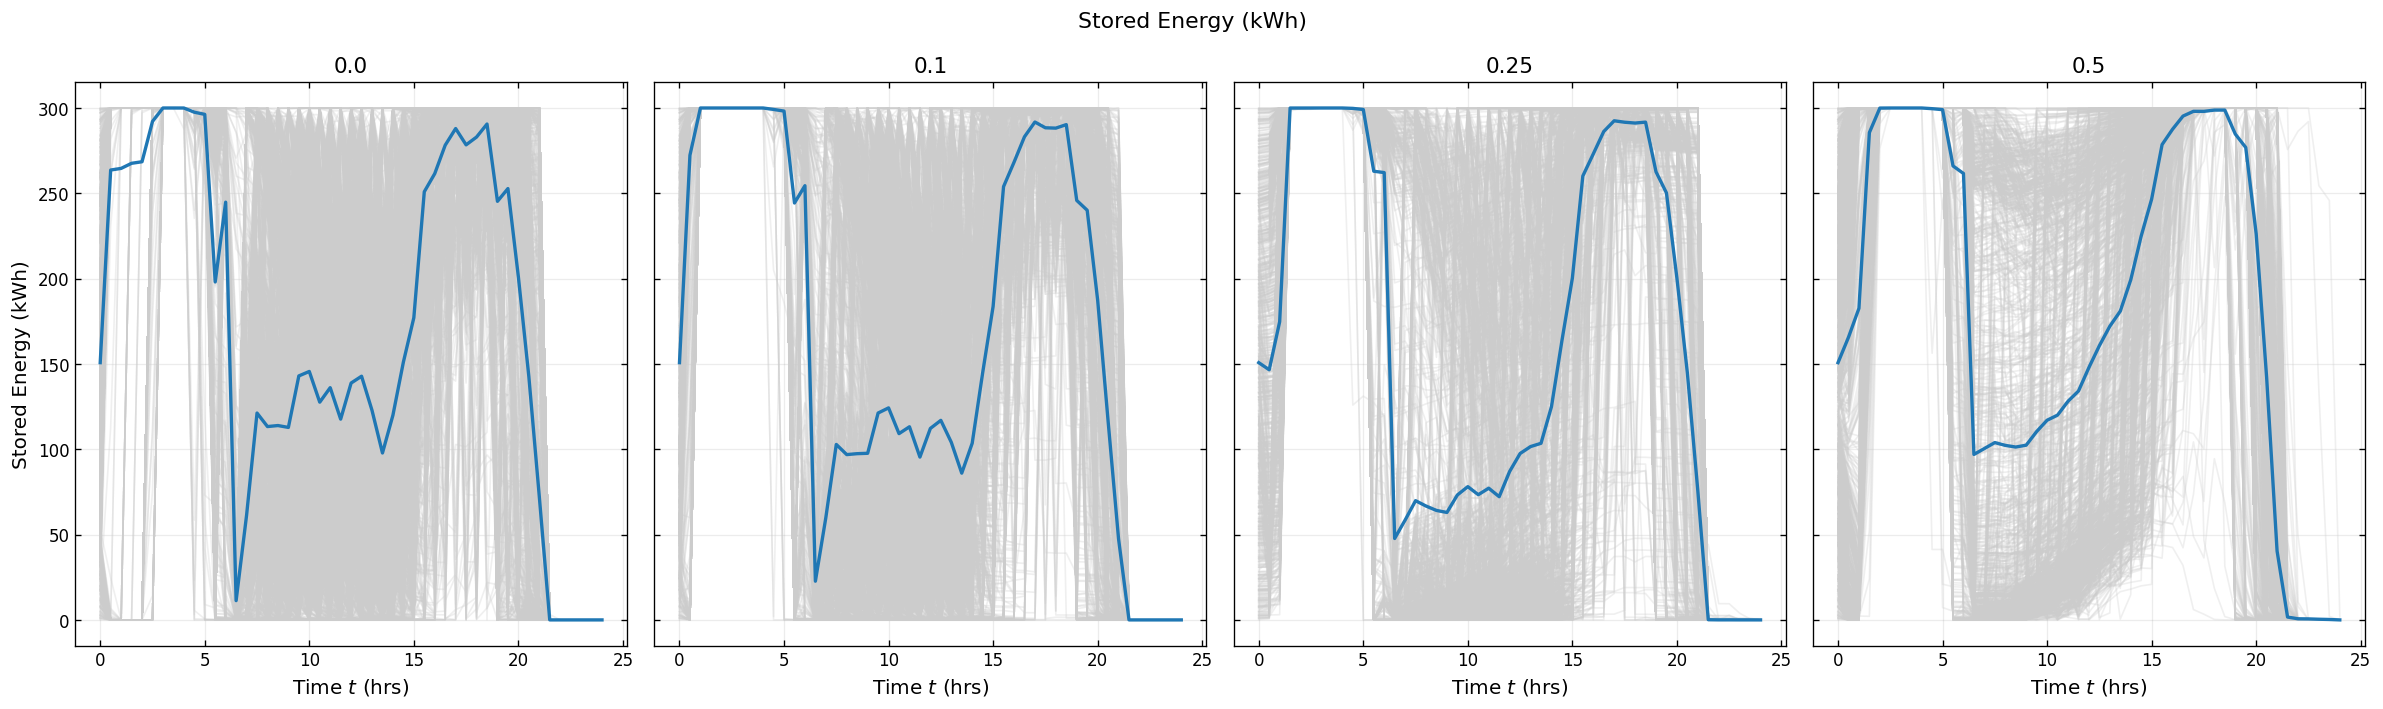

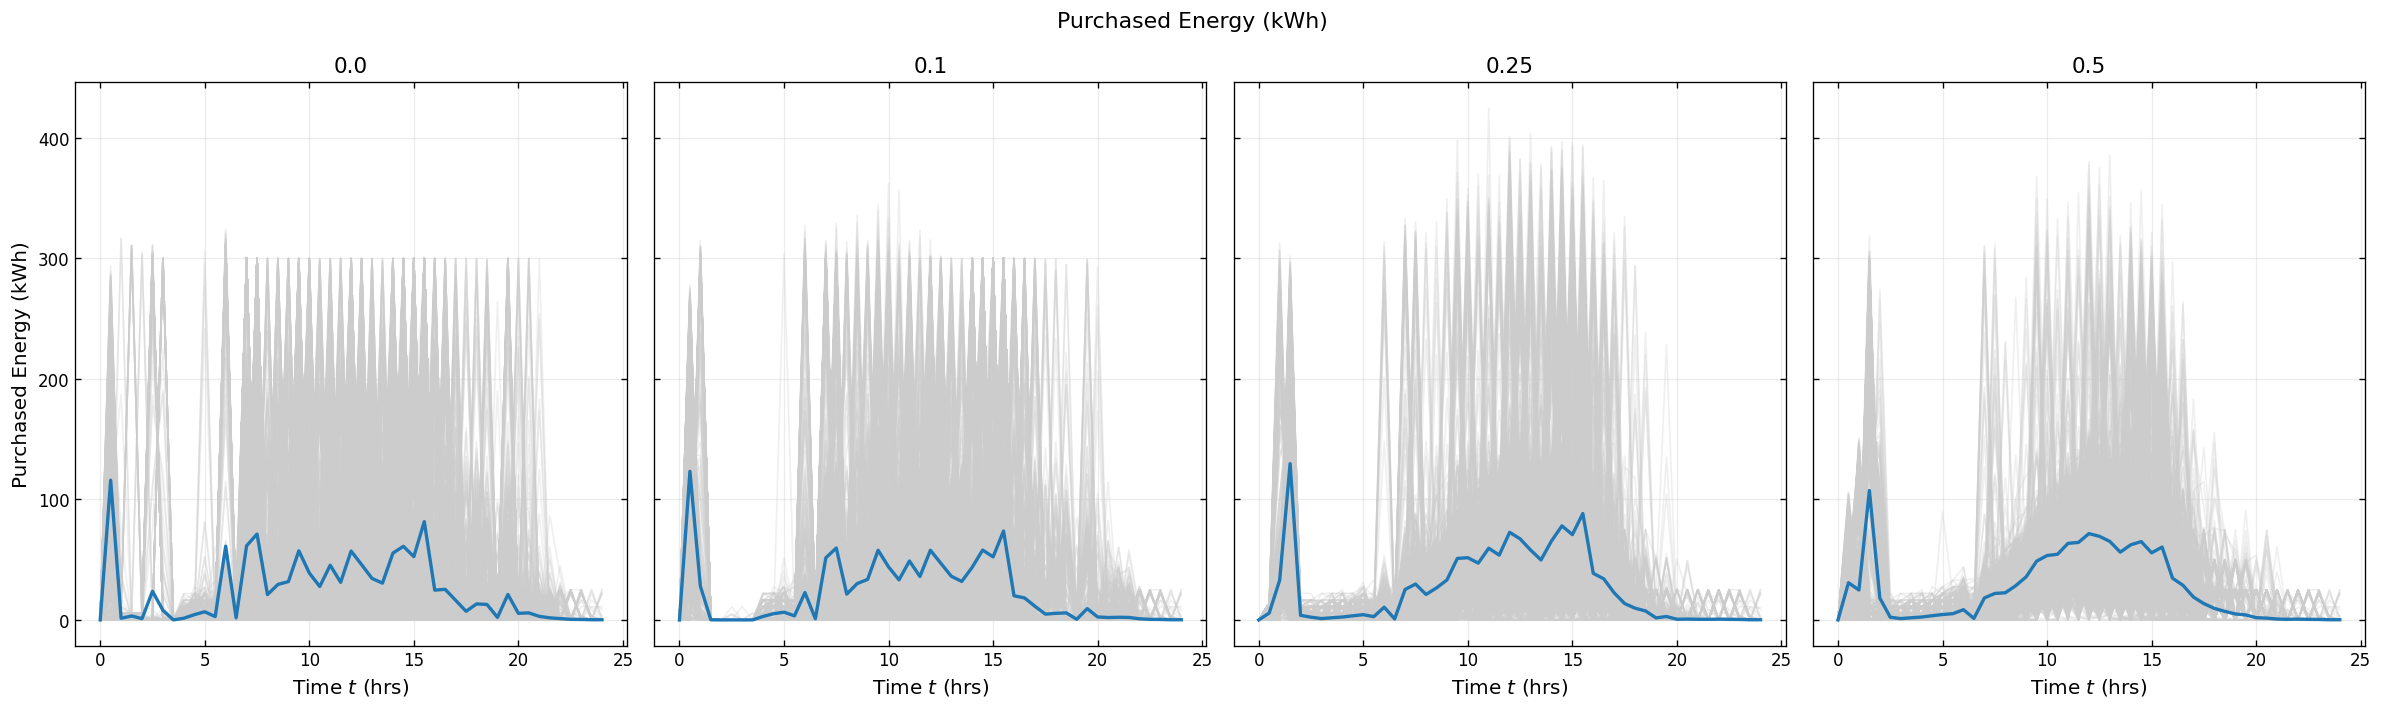

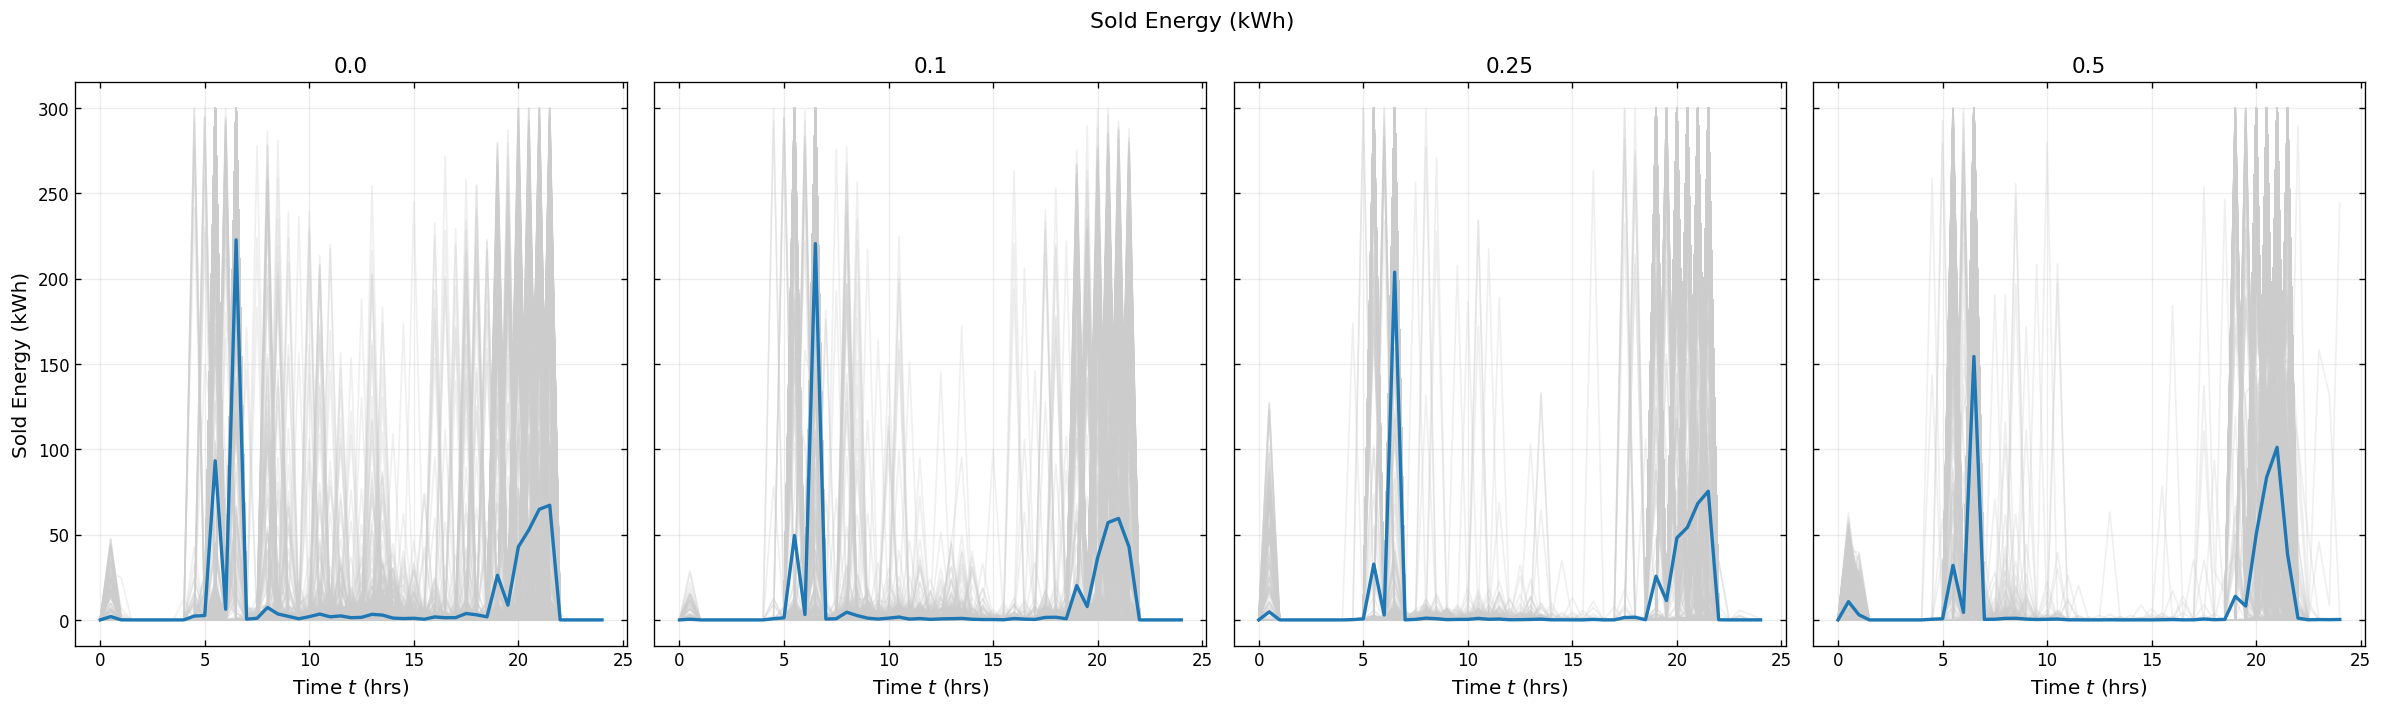

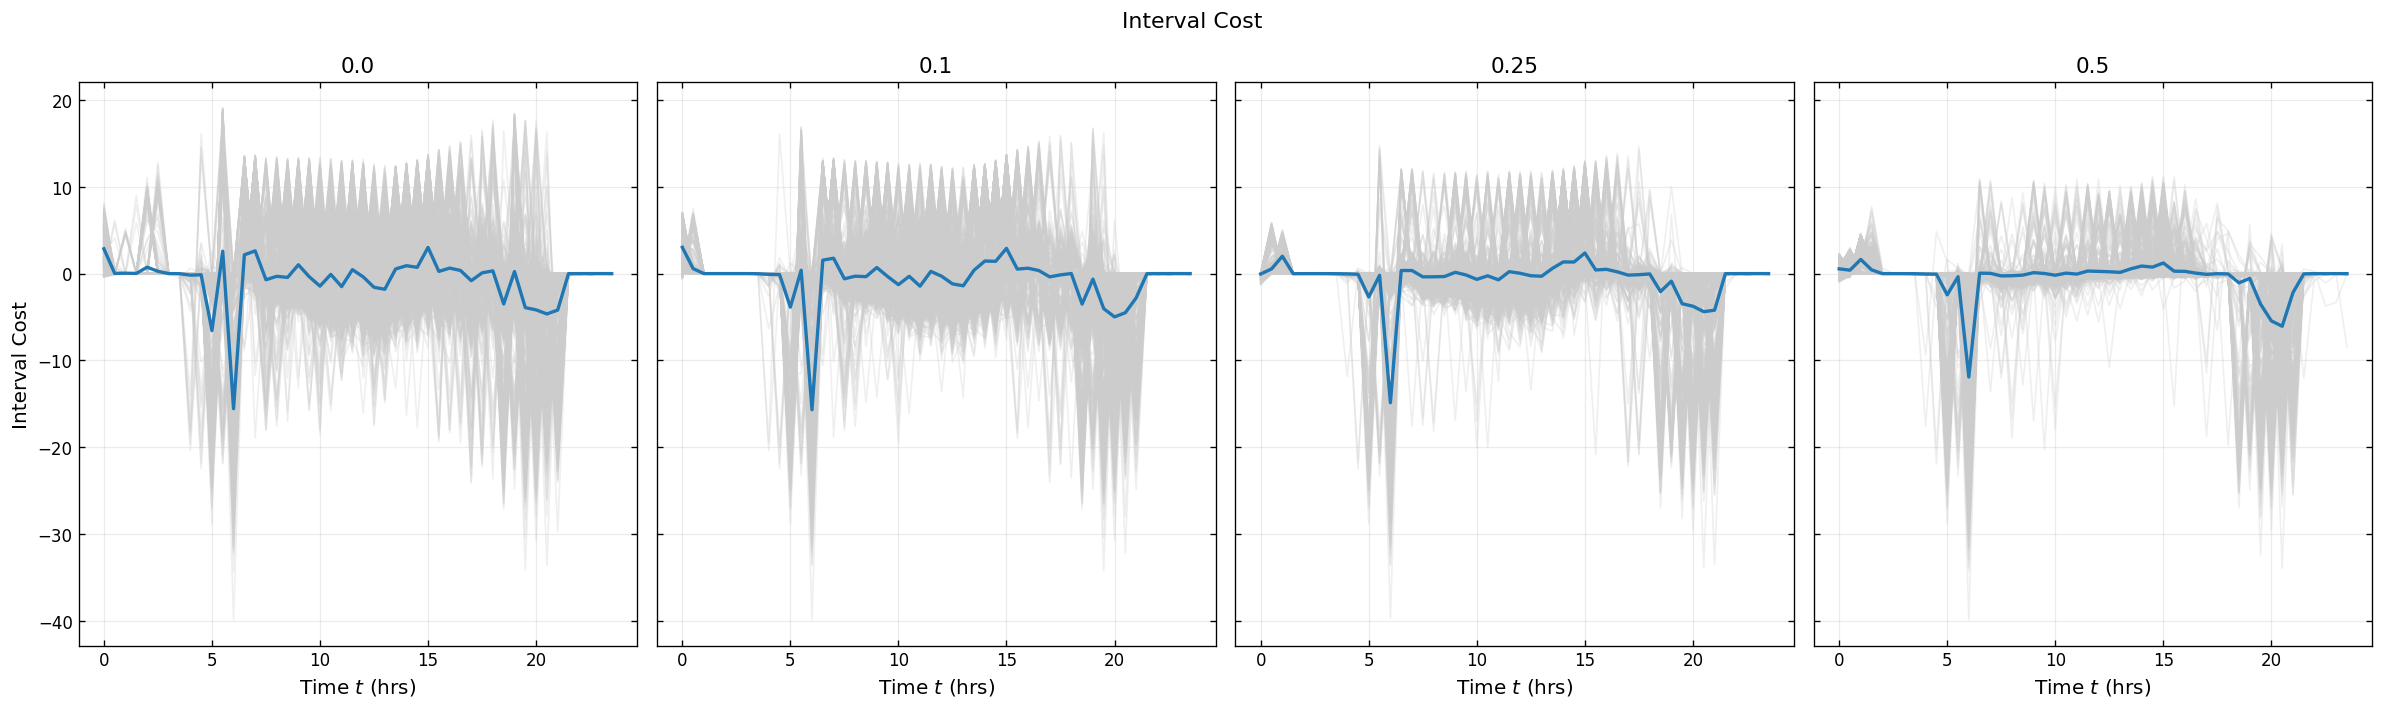

In [12]:

SAVE_DIR = "../figures/lambda_experiments"

plots = [
    ("eta",   r"Control $\eta$",             "control_eta.pdf"),
    ("delta", r"Control $\delta$",           "control_delta.pdf"),
    ("gamma", r"Control $\gamma$",           "control_gamma.pdf"),
    ("q",     "EV Power Allocated (kW)",     "ev_power_allocated.pdf"),
    ("E",     "Stored Energy (kWh)",         "stored_energy.pdf"),
    ("Ub",    "Purchased Energy (kWh)",      "purchased_energy.pdf"),
    ("Us",    "Sold Energy (kWh)",           "sold_energy.pdf"),
    ("c",     "Interval Cost",               "interval_cost.pdf"),
]

for key, ylabel, filename in plots:

    full_path = os.path.join(SAVE_DIR, filename)

    plot_variable_across_policies(
        rollout_results,
        key,
        ylabel,
        filename=full_path
    )

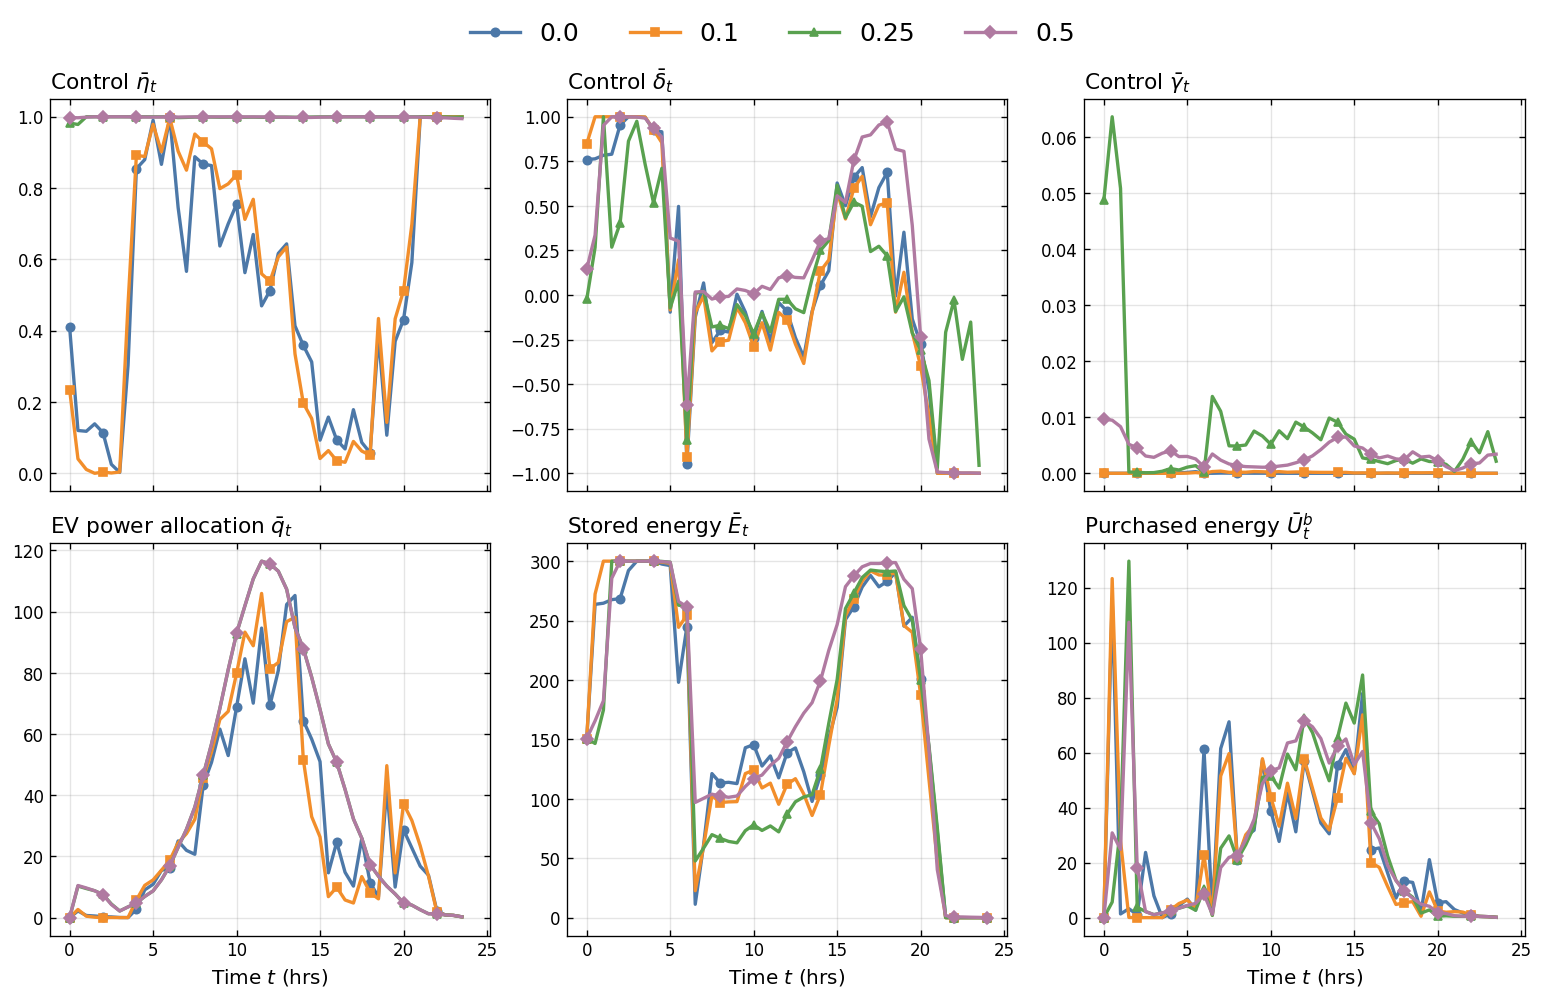

(<Figure size 1560x960 with 6 Axes>,
 array([<Axes: title={'left': 'Control $\\bar{\\eta}_t$'}>,
        <Axes: title={'left': 'Control $\\bar{\\delta}_t$'}>,
        <Axes: title={'left': 'Control $\\bar{\\gamma}_t$'}>,
        <Axes: title={'left': 'EV power allocation $\\bar{q}_t$'}, xlabel='Time $t$ (hrs)'>,
        <Axes: title={'left': 'Stored energy $\\bar{E}_t$'}, xlabel='Time $t$ (hrs)'>,
        <Axes: title={'left': 'Purchased energy $\\bar{U}^{b}_t$'}, xlabel='Time $t$ (hrs)'>],
       dtype=object))

In [13]:
plot_controls_summary(
    rollout_results,
    save_path="../figures/lambda_experiments/controls_summary.pdf"
)

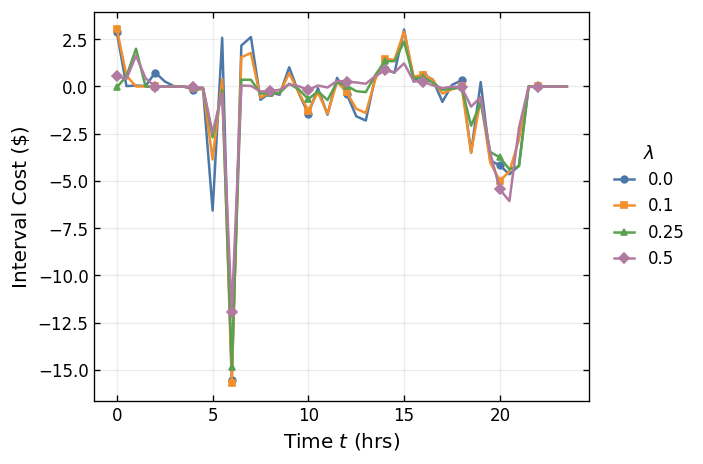

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))

colors = cycle([
    "#4C78A8",
    "#F28E2B",
    "#59A14F",
    "#B07AA1"
])

markers = cycle(["o", "s", "^", "D"])

for lambda_, history in rollout_results.items():
    cost = history["cost"].detach().numpy()
    time = history["time"].detach().numpy()

    cost_mean = cost.mean(axis=1)

    ax.plot(
        time[:-1],
        cost_mean,
        color=next(colors),
        marker=next(markers),
        markersize=4,
        markevery=4,
        lw=1.5,
        label=lambda_,
    )

ax.set_xlabel(r"Time $t$ (hrs)")
ax.set_ylabel("Interval Cost ($)")

ax.legend(
    title=r"$\lambda$",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    handlelength=1.2
)

plt.tight_layout()
plt.savefig("../figures/lambda_experiments/cost_lambda_comparison.pdf")
plt.show()

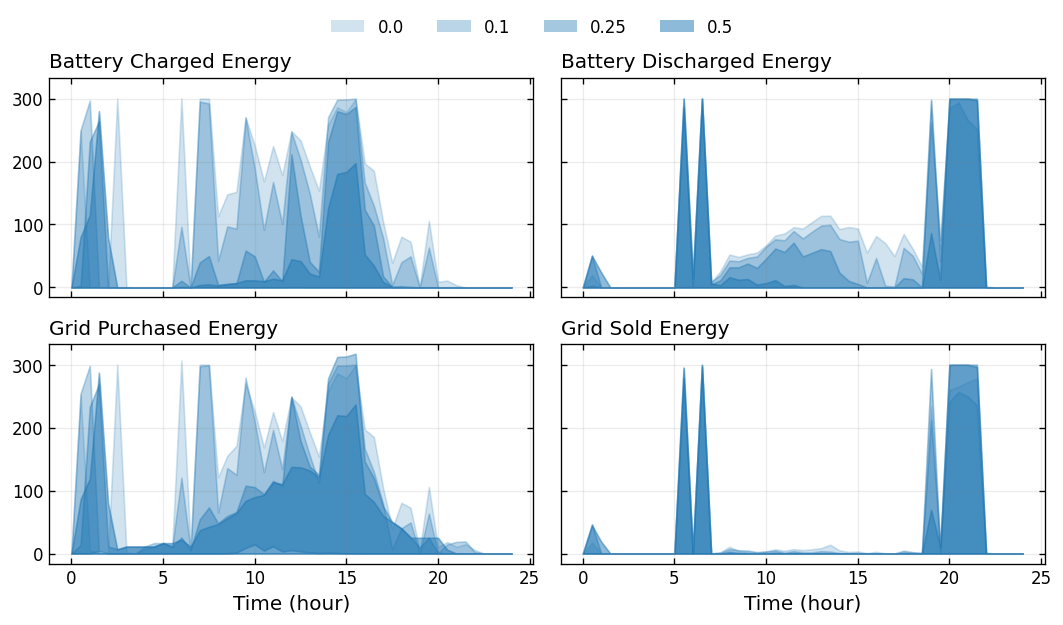

In [15]:
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)

titles = (
    "EV Power Allocated",
    "Battery Charged Energy",
    "Battery Discharged Energy",
    "Grid Purchased Energy",
    "Grid Sold Energy"
)

for i, ax in enumerate(axes.flatten()):

    ax, handles, labels = plot_policy_percentile_bands(
        rollout_results, "endog", i+1, show_mean=False, ax=ax, add_legend=False
    )
    ax.set_title(titles[i+1], loc="left", size=12)
    if i > 1: ax.set_xlabel("Time (hour)")

fig.legend(
    handles,
    labels,
    handler_map={tuple: HandlerTuple(ndivide=1)},
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    frameon=False
)

plt.tight_layout()
plt.savefig("../figures/lambda_experiments/lambda_trajectories_dispersion.pdf")
plt.show()

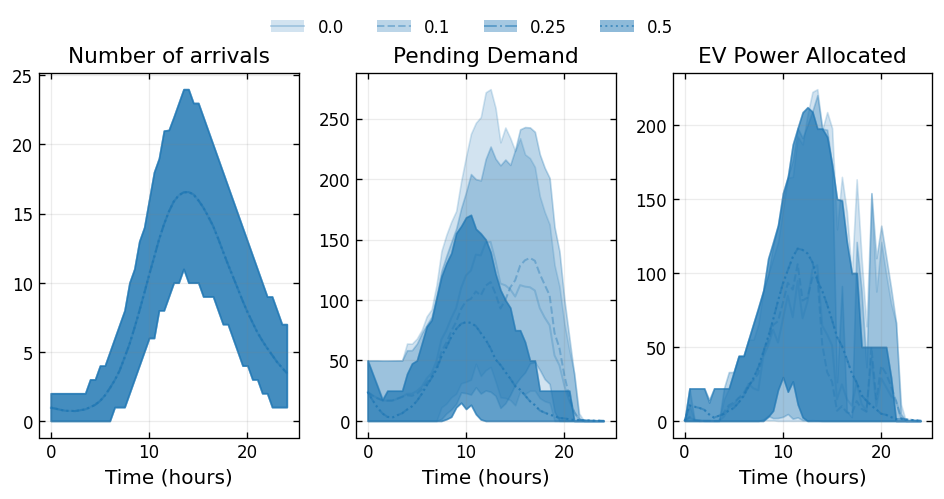

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(8, 4))
ax = ax.flatten()

_, _ ,_ = plot_policy_percentile_bands(rollout_results, "state", 0, ax=ax[0], add_legend=False)
ax[0].set_title("Number of arrivals")

_, _, _ = plot_policy_percentile_bands(rollout_results, "state", 1, ax=ax[1], add_legend=False)
ax[1].set_title("Pending Demand" )

_, handles, labels = plot_policy_percentile_bands(rollout_results, "endog", 0, ax=ax[2], add_legend=False)
ax[2].set_title("EV Power Allocated" )

fig.legend(
    handles,
    labels,
    handler_map={tuple: HandlerTuple(ndivide=1)},
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    frameon=False
)

for a in ax:
    a.set_xlabel("Time (hours)")

plt.tight_layout()
plt.show()

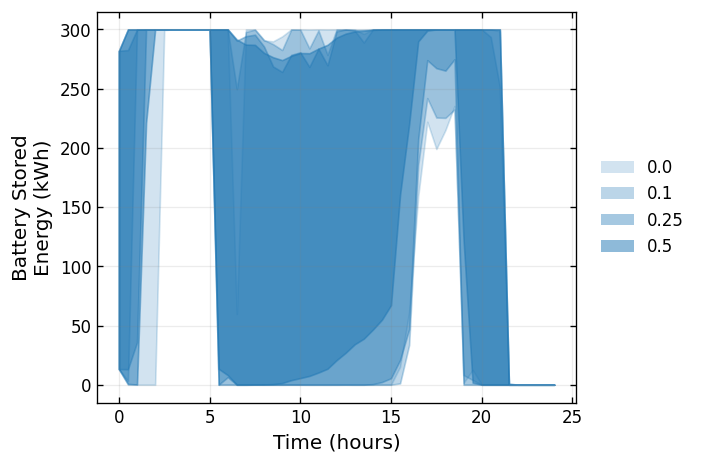

In [17]:
ax, handles, legend = plot_policy_percentile_bands(
    rollout_results, "state", 2, 
    add_legend=False, show_mean=False
)

ax.legend(
    handles,
    labels,
    handler_map={tuple: HandlerTuple(ndivide=1)},
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    frameon=False,
)

plt.xlabel("Time (hours)")
plt.ylabel("Battery Stored\nEnergy (kWh)")
plt.tight_layout()
plt.show()

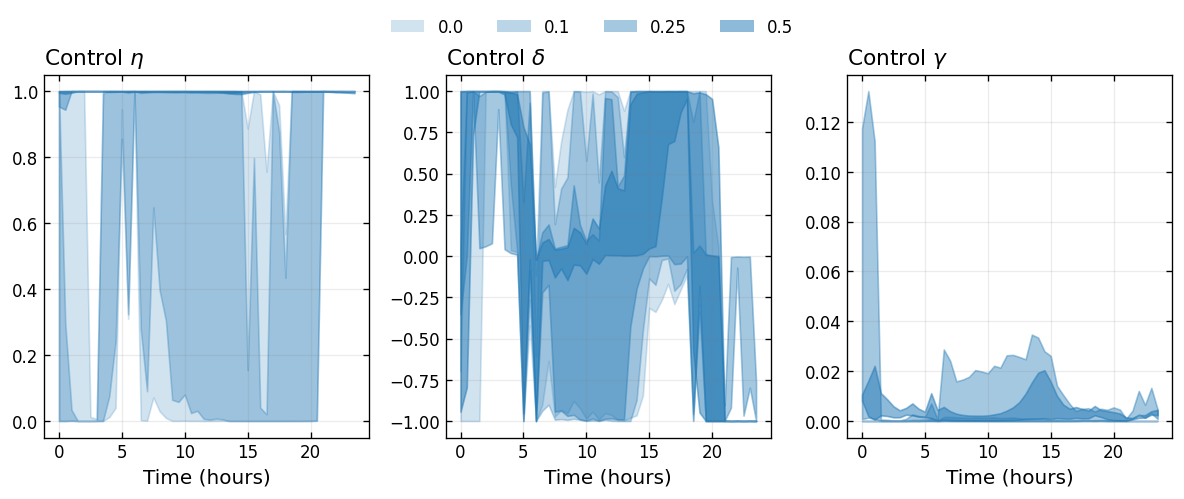

In [18]:
fig, axes = plt.subplots(1, 3, sharex=True, figsize=(10,4))

titles = (
    "Control $\eta$", "Control $\delta$", "Control $\gamma$"
)

for i, ax in enumerate(axes.flatten()):
    ax, _ ,_ = plot_policy_percentile_bands(
        rollout_results, "control", i, 
        ax=ax, add_legend=False, show_mean=False
    )
    ax.set_xlabel("Time (hours)")
    ax.set_title(titles[i], loc="left")

fig.legend(
    handles,
    labels,
    handler_map={tuple: HandlerTuple(ndivide=1)},
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    frameon=False
)

plt.tight_layout()
plt.show()

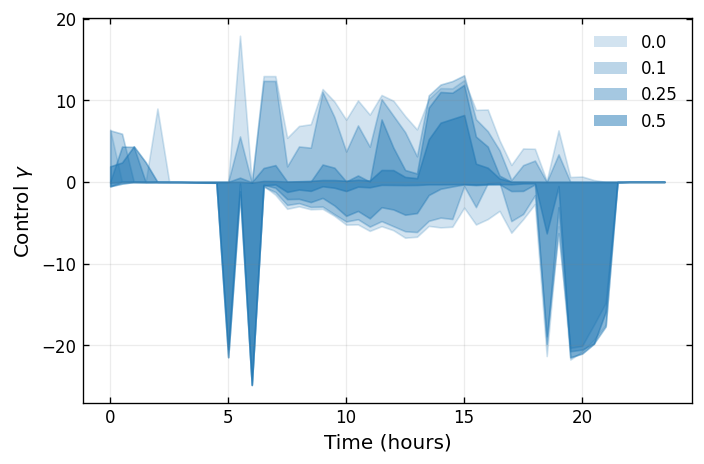

In [19]:
ax, _ ,_ = plot_policy_percentile_bands(rollout_results, "cost", show_mean=False)

plt.xlabel("Time (hours)")
plt.ylabel("Control $\gamma$")
plt.tight_layout()
plt.show()

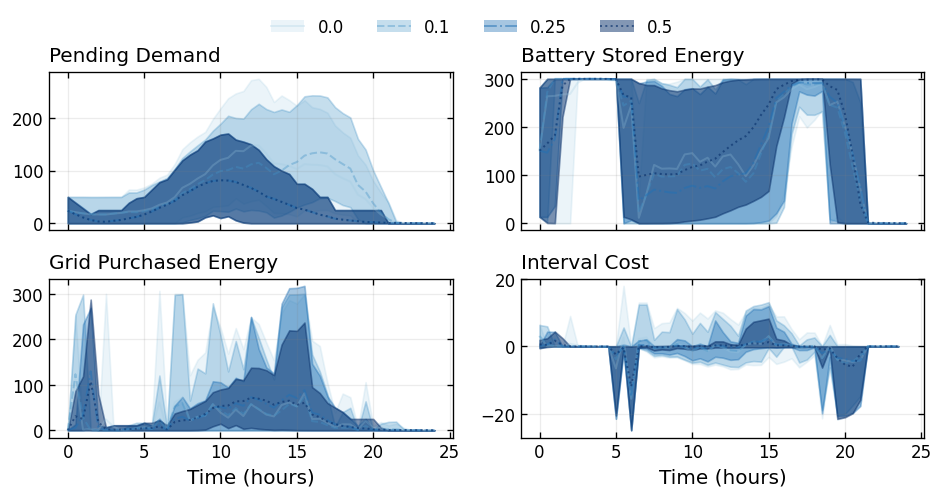

In [38]:
plt.style.use("../styles/notebook.mplstyle")

fig, ax = plt.subplots(2, 2, figsize=(8, 4), sharex=True)
ax = ax.flatten()

colors = [
    "#9ecae1",  # λ=0.0
    "#4292c6",  # λ=0.1
    "#2171b5",  # λ=0.25
    "#08306b",  # λ=0.5
]

plot_policy_percentile_bands(rollout_results, "state", 1, ax=ax[0], add_legend=False, colors=colors)
ax[0].set_title("Pending Demand", loc="left", size=12)

plot_policy_percentile_bands(rollout_results, "state", 2, ax=ax[1], add_legend=False, colors=colors)
ax[1].set_title("Battery Stored Energy", loc="left", size=12)

plot_policy_percentile_bands(rollout_results, "endog", 3, ax=ax[2], add_legend=False, colors=colors)
ax[2].set_title("Grid Purchased Energy", loc="left", size=12)
ax[2].set_xlabel("Time (hours)")

_, handles, labels = plot_policy_percentile_bands(rollout_results, "cost", ax=ax[3], add_legend=False, colors=colors)
ax[3].set_title("Interval Cost", loc="left", size=12)
ax[3].set_xlabel("Time (hours)")

fig.legend(
    handles,
    labels,
    handler_map={tuple: HandlerTuple(ndivide=1)},
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    frameon=False
)

plt.tight_layout()
plt.savefig("../figures/lambda_experiments/lambda_trajectory_dispersion.pdf")
plt.show()

In [21]:
from source.utils import summarize_histories

df = summarize_histories(rollout_results)
print(df.round(4))

                 0.0       0.1      0.25       0.5
N_mean        7.6744    7.6744    7.6744    7.6744
N_std         6.1878    6.1878    6.1878    6.1878
D_mean       62.1258   60.3343   27.2467   27.2181
D_std        64.7483   61.3808   37.8791   37.8524
E_mean      172.3015  169.6410  162.0134  183.4506
E_std       130.3597  132.0000  136.1219  130.2908
P_mean        0.0420    0.0420    0.0420    0.0420
P_std         0.0157    0.0157    0.0157    0.0157
eta_mean      0.5213    0.5317    0.9986    0.9990
eta_std       0.4676    0.4723    0.0054    0.0016
delta_mean    0.0821    0.0560    0.0657    0.2112
delta_std     0.7801    0.7529    0.5611    0.7045
gamma_mean    0.0000    0.0001    0.0073    0.0032
gamma_std     0.0001    0.0003    0.0176    0.0034
q_mean       29.2306   29.5980   36.6713   36.6768
q_std        50.2939   49.4564   51.1702   51.1864
ec_mean      20.9094   15.8846   10.4868    7.9273
ec_std       61.7956   55.3148   44.4298   33.7310
ed_mean      23.9861   18.9614 

In [22]:
import os

SAVE_DIR = "../checkpoints/rollouts"
os.makedirs(SAVE_DIR, exist_ok=True)

df.to_csv(
    os.path.join(
        SAVE_DIR,
        "lambda_experiment_summary.csv"
    )
)

with open(
    os.path.join(
        SAVE_DIR,
        "lambda_experiment_summary.tex"
    ),
    "w"
) as f:
    f.write(df.round(4).to_latex())

print(df.round(4))

                 0.0       0.1      0.25       0.5
N_mean        7.6744    7.6744    7.6744    7.6744
N_std         6.1878    6.1878    6.1878    6.1878
D_mean       62.1258   60.3343   27.2467   27.2181
D_std        64.7483   61.3808   37.8791   37.8524
E_mean      172.3015  169.6410  162.0134  183.4506
E_std       130.3597  132.0000  136.1219  130.2908
P_mean        0.0420    0.0420    0.0420    0.0420
P_std         0.0157    0.0157    0.0157    0.0157
eta_mean      0.5213    0.5317    0.9986    0.9990
eta_std       0.4676    0.4723    0.0054    0.0016
delta_mean    0.0821    0.0560    0.0657    0.2112
delta_std     0.7801    0.7529    0.5611    0.7045
gamma_mean    0.0000    0.0001    0.0073    0.0032
gamma_std     0.0001    0.0003    0.0176    0.0034
q_mean       29.2306   29.5980   36.6713   36.6768
q_std        50.2939   49.4564   51.1702   51.1864
ec_mean      20.9094   15.8846   10.4868    7.9273
ec_std       61.7956   55.3148   44.4298   33.7310
ed_mean      23.9861   18.9614 